# LeetCode #69: Sqrt(x)

https://leetcode.com/problems/sqrtx/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Linear Scan | O(√x) | O(1) | Increment i until i² > x |
| Newton's Method | O(log x) | O(1) | Quadratic convergence |
| **Binary Search ★** | **O(log x)** | **O(1)** | Search [0, x/2], track largest valid mid |

---

## Understanding the Methods

### Brute Force (Linear Scan)
Iterate i from 0 upward; when i² > x, return i−1. Works but O(√x) is slow for large x.

### Optimal: Binary Search ★
Search the space [1, x/2] for the largest integer whose square ≤ x.
- If mid² == x: exact answer.
- If mid² < x: valid candidate; record `ans = mid` and search higher (lo = mid+1).
- If mid² > x: too large; search lower (hi = mid−1).
- Important: use `long` for mid*mid to avoid 32-bit overflow near INT_MAX.

**Constraints:**
* 0 <= x <= 2^31 - 1

## Solutions

### C#

In [ ]:
public class Solution {
    public int MySqrt(int x) {
        if (x < 2) return x;
        int lo = 1, hi = x / 2, ans = 1;
        while (lo <= hi) {
            int mid = lo + (hi - lo) / 2;
            long sq = (long)mid * mid;
            if (sq == x)      return mid;
            else if (sq < x) { ans = mid; lo = mid + 1; }
            else               hi = mid - 1;
        }
        return ans;
    }
}

### Python

In [ ]:
class Solution:
    def mySqrt(self, x: int) -> int:
        if x < 2:
            return x
        lo, hi, ans = 1, x // 2, 1
        while lo <= hi:
            mid = lo + (hi - lo) // 2
            sq = mid * mid
            if sq == x:
                return mid
            elif sq < x:
                ans = mid
                lo = mid + 1
            else:
                hi = mid - 1
        return ans

### Go

In [ ]:
func mySqrt(x int) int {
    if x < 2 {
        return x
    }
    lo, hi, ans := 1, x/2, 1
    for lo <= hi {
        mid := lo + (hi-lo)/2
        sq := mid * mid
        if sq == x {
            return mid
        } else if sq < x {
            ans = mid
            lo = mid + 1
        } else {
            hi = mid - 1
        }
    }
    return ans
}

### Rust

In [ ]:
impl Solution {
    pub fn my_sqrt(x: i32) -> i32 {
        if x < 2 { return x; }
        let (mut lo, mut hi, mut ans) = (1i64, (x / 2) as i64, 1i64);
        let xv = x as i64;
        while lo <= hi {
            let mid = lo + (hi - lo) / 2;
            let sq = mid * mid;
            if sq == xv       { return mid as i32; }
            else if sq < xv   { ans = mid; lo = mid + 1; }
            else               { hi = mid - 1; }
        }
        ans as i32
    }
}

## Example Scenarios

### 1. Common Case — Perfect Square
**Input:** `x = 36`

Search range $[1, 18]$. Step 1: $mid = 9$, $9^2 = 81 > 36 \Rightarrow hi = 8$. Step 2: $mid = 4$, $16 < 36 \Rightarrow ans = 4, lo = 5$. Step 3: $mid = 6$, $36 = 36 \Rightarrow$ return 6.

**Why it’s useful:** Validates the exact-match short circuit ($mid^2 = x$). Only 3 iterations for a perfect square.

### 2. Slightly Complex — Non-Perfect Square
**Input:** `x = 17`

$\sqrt{17} \approx 4.123$, so $\lfloor \sqrt{17} \rfloor = 4$. The search never finds $mid^2 = x$ exactly. Instead, the $ans$ variable tracks the last $mid$ where $mid^2 < x$. After 4 iterations, $lo > hi$ and we return $ans = 4$.

**Why it’s tricky:** Tests the floor-tracking mechanism. Without the $ans$ variable, the algorithm has no way to return the correct non-exact result.

### 3. Edge Case: Time Factor — x = 2,147,483,647 (INT_MAX)
**Input:** `x = 2147483647` ($= 2^{31} - 1$)

Search range $[1, 1073741823]$. $\log_2(1073741823) \approx 30$ iterations. The answer is $46340$ since $46340^2 = 2{,}147{,}395{,}600 \le x$ but $46341^2 = 2{,}147{,}487{,}281 > x$.

**Why it’s tricky:** Maximum possible input forces $\approx 31$ binary search steps. A linear scan would need 46,340 iterations — binary search is $\approx 1500\times$ faster.

### 4. Edge Case: Space Factor — Base Cases x = 0 and x = 1
**Input:** `x = 0` and `x = 1`

Both handled by the guard `if x < 2 return x` before any allocation. The search never runs. Only 3 variables ($lo$, $hi$, $ans$) exist on the stack regardless of input.

**Why it’s tricky:** Without the base-case guard, $hi = x / 2 = 0$ for $x = 0$, creating an empty search range that returns the uninitialized $ans$. For $x = 1$, $hi = 0$ also skips the loop.

### 5. Almost-Impossible but Plausible — x = 2,147,395,600 (= 46340\u00b2)
**Input:** `x = 2147395600`

This is the largest perfect square that fits in int32. $46340 \times 46340 = 2{,}147{,}395{,}600$ fits in int32, but $46341 \times 46341 = 2{,}147{,}487{,}281 > 2^{31}-1$ overflows. Without casting $mid \times mid$ to `long`, the overflow produces a negative number, causing the search to go in the wrong direction.

**Why it’s tricky:** The classic int32 overflow trap. The code **must** use `(long)mid * mid` to avoid undefined behavior at the boundary.


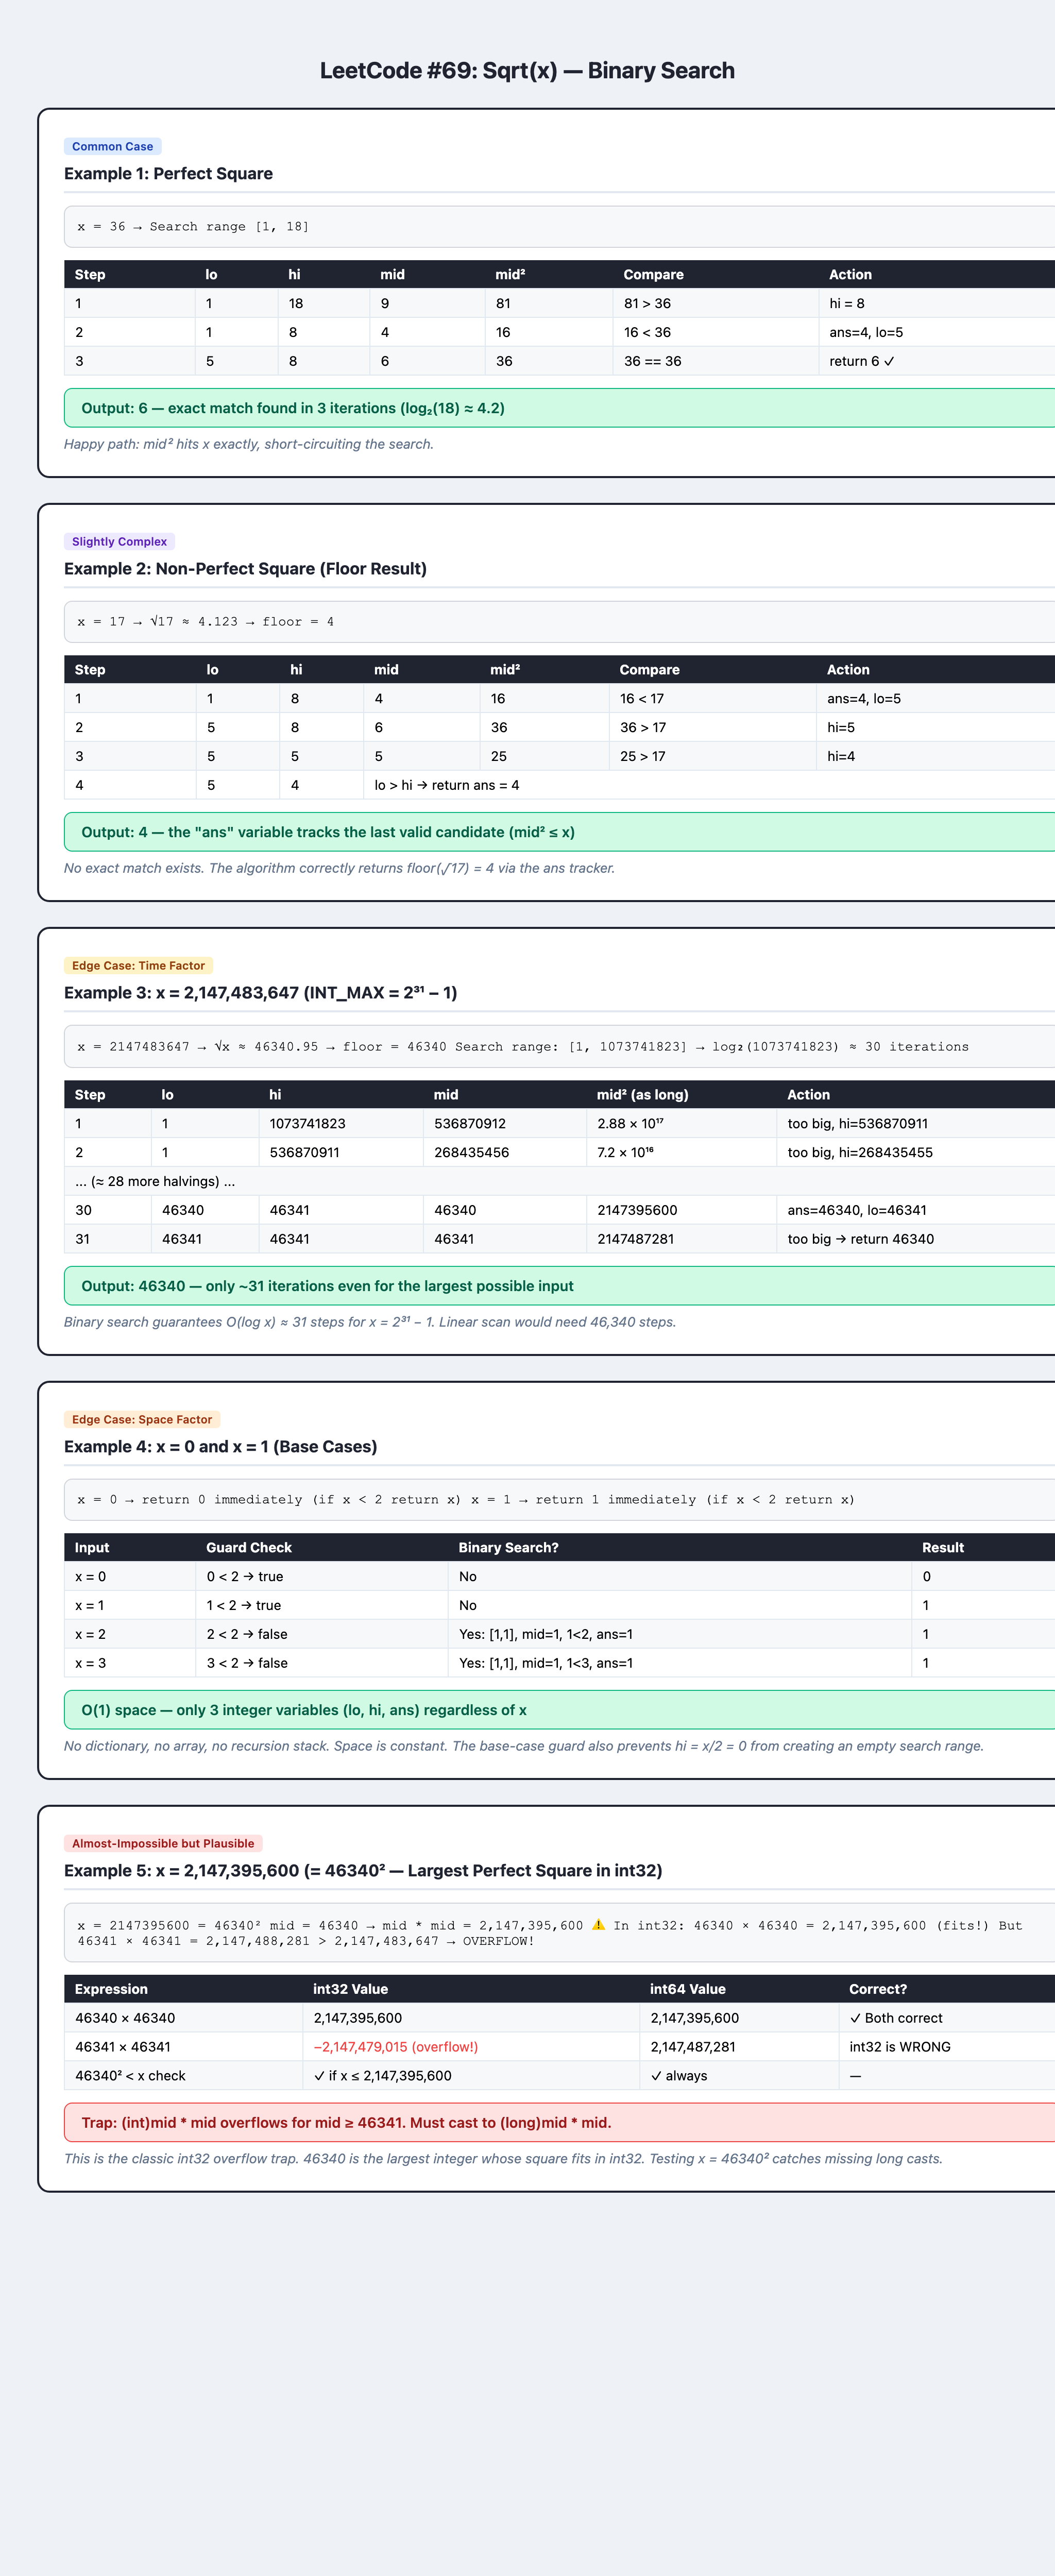